In [1]:
import os

import numpy as np
np.set_printoptions(suppress=True)
import pandas as pd
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import gaussian_kde
from scipy.ndimage.filters import gaussian_filter

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import (LinearLocator, MultipleLocator, FormatStrFormatter)
from matplotlib.dates import MONDAY
from matplotlib.dates import MonthLocator, WeekdayLocator, DateFormatter
from matplotlib import gridspec
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.colors as mcolors
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
%matplotlib inline

print("Package is ready.")

Package is ready.


In [2]:
plt.rcParams['figure.figsize'] = ((8/2.54), (6/2.54))
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.default"] = "rm"
plt.rcParams.update({'font.size': 11})
MARKER_SIZE = 15
raw_cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
raw_cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

plt.rcParams['axes.spines.top'] = False
# plt.rcParams['axes.edgecolor'] = 
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

In [3]:
def make_patch_spines_invisible(ax):
    ax.set_frame_on(True)
    ax.patch.set_visible(False)
    for sp in ax.spines.values():
        sp.set_visible(False)

In [4]:
cmap = ['#e94d5b', '#f4a6ad', '#1bb1e7', '#25b575', '#f9a54f']
cmap_m = ['#f4a6ad', '#ffffff', '#86d6f2', '#8de7be', '#fccfa2']

In [5]:
cmap_rgb = []
for _ in cmap:
    ll = _.lstrip('#')
    cmap_rgb.append(tuple(int(ll[i:i+2], 16) for i in (0, 2, 4)))
cmap_m_rgb = []
for _ in cmap_m:
    ll = _.lstrip('#')
    cmap_m_rgb.append(tuple(int(ll[i:i+2], 16) for i in (0, 2, 4)))

In [6]:
N = 256
colmaps = []
for l in cmap_rgb:
    vals = np.ones((N, 4))
    vals[:, 0] = np.linspace(1, l[0]/256, N)
    vals[:, 1] = np.linspace(1, l[1]/256, N)
    vals[:, 2] = np.linspace(1, l[2]/256, N)
    colmaps.append(ListedColormap(vals))

In [7]:
# N = 256
# colmaps = []
# for l, ll in zip(cmap_rgb, cmap_m_rgb):
#     vals = np.ones((N, 4))
#     vals[:, 0] = np.linspace(ll[0]/256, l[0]/256, N)
#     vals[:, 1] = np.linspace(ll[1]/256, l[1]/256, N)
#     vals[:, 2] = np.linspace(ll[2]/256, l[2]/256, N)
#     colmaps.append(ListedColormap(vals))

# Graphical abstract

### Workflow for graph abstract

In [8]:
PAP_DIRECTORY = '../data/pap/'
file_list = os.listdir(PAP_DIRECTORY)
papset_list = [file for file in file_list if file.endswith('.csv')]
papset_list.sort()

In [9]:
pap_indices = []
for FILENAME in papset_list:
    env_df = pd.read_csv(PAP_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df.index = pd.DatetimeIndex(env_df.index)
    pap_indices.append([env_df.index[0], env_df.index[-1]])
pap_indices = np.array(pap_indices)

In [10]:
TOM_DIRECTORY = '../data/tom/'
file_list = os.listdir(TOM_DIRECTORY)
tomset_list = [file for file in file_list if file.endswith('.csv')]
tomset_list.sort()

In [11]:
tom_indices = []
for FILENAME in tomset_list:
    env_df = pd.read_csv(TOM_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df.index = pd.DatetimeIndex(env_df.index)
    tom_indices.append([env_df.index[0], env_df.index[-1]])
tom_indices = np.array(tom_indices)

In [12]:
temp_ = []
probs = [0.5, 0.6, 0.4, 0.8, 0.7]
for column, prob in zip(env_df.columns, probs):
    temp_.append(env_df[column].sample(frac=prob).reindex(env_df.index))
loss_df = pd.concat(temp_, axis=1)

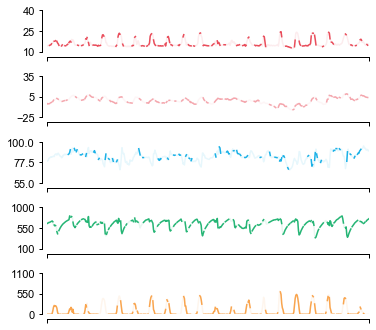

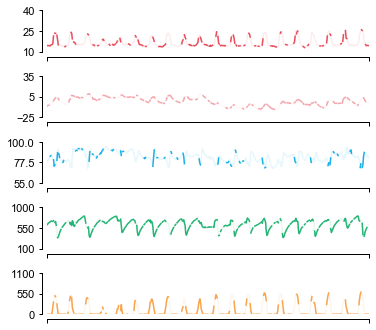

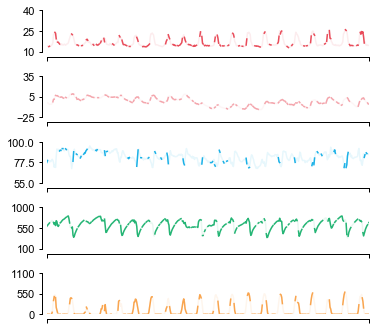

In [13]:
x_t = np.arange(env_df.shape[0])
Y_BOUNDS = [[10, 40], [-25, 35], [55, 100], [100, 1000], [0, 1100]]
for i in np.random.randint(55, size=3):
    fig = plt.figure(figsize=((8/2.54)*1.7, (6/2.54)*2))
    grid = plt.GridSpec(5,1)
    for _ in range(5):
        ax = plt.subplot(grid[_])
        measured2 = ax.plot(x_t, env_df.values[:, _], c=cmap[_], alpha=0.1)
        measured1 = ax.plot(x_t, loss_df.values[:, _], c=cmap[_])
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_position(('outward', 5))
        ax.spines['bottom'].set_position(('outward', 5))
        ax.set_xbound([24*i, 24*(i+20)])
        ax.set_ybound(Y_BOUNDS[_])
        ax.xaxis.set_major_locator(LinearLocator(2))
        ax.yaxis.set_major_locator(LinearLocator(3))
        ax.axes.xaxis.set_ticklabels([])

    fig.tight_layout()
    fig.savefig('./figures/GA_1_%2d.svg' % i, transparent=True, format='svg')
    plt.show()

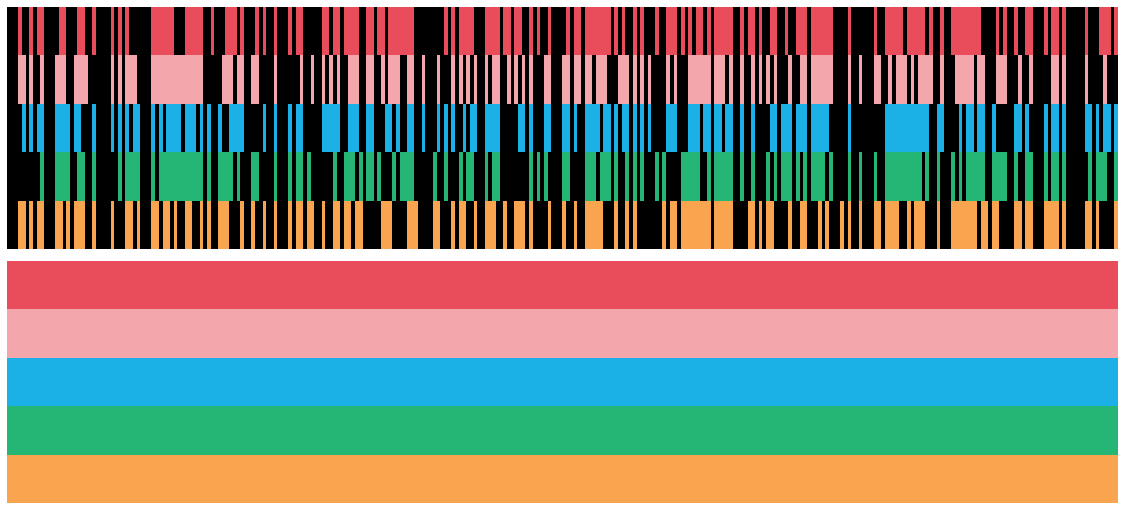

In [14]:
temp_current = []
temp_prev = []
temp_next = []
temp_mask = []
temp_label = []
i = 0

gs = gridspec.GridSpec(10, 1)
fig = plt.figure(figsize=((8/2.54)*5, (6/2.54)*3*5))
for FILENAME in papset_list[:1]:
    env_df = pd.read_csv(PAP_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate().values
    
    for ___ in [0.3]:
#         np.random.seed(3101)
        null_prob = 0.3
        mask = np.random.choice(2, env_df.size, p=[null_prob, 1-null_prob]).reshape(env_df.shape)
#         np.random.seed(4564)
        raw_null_prob = ___
        raw_indices = np.random.choice(np.arange(env_df.shape[0]),
                                       replace=False, size=int(env_df.shape[0] * raw_null_prob))

        mask[raw_indices, :] = 0
        missing_df = np.concatenate([[mask.T[0]*.2], [mask.T[1]*.4],
                                     [mask.T[2]*.6], [mask.T[3]*.8], [mask.T[4]]])

        ax0 = fig.add_subplot(gs[i])

        ax0.spines['right'].set_visible(False)
        ax0.spines['left'].set_position(('outward', 5))
        ax0.spines['bottom'].set_visible(False)

        colmap = matplotlib.colors.ListedColormap(['#000000', '#e94d5b', '#f4a6ad', '#1bb1e7', '#25b575', '#f9a54f'])
# cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
# cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

        plt.setp(ax0.get_xticklabels(), visible=False)
        plt.setp(ax0.get_yticklabels(), visible=False)
        plt.axis('off')
        a = ax0.imshow(missing_df[:, 500:800], aspect='auto', cmap=colmap)

        # ax1 = fig.add_subplot(gs[1])
        # ax1.imshow(null_50, aspect='auto', cmap=newcmp)
        # ax1.spines['right'].set_visible(False)
        # ax1.spines['left'].set_position(('outward', 5))
        # ax1.spines['bottom'].set_position(('outward', 5))


        # x_label = ('Oct', 'Feb', 'Jun', 'Oct', 'Feb', 'Jun')
        # x_pos = np.arange(len(x_label))
        # ax1.xaxis.set_major_locator(LinearLocator(len(x_pos)))
        # ax1.set_xticklabels(x_label)


        i += 1

for FILENAME in papset_list[:1]:
    env_df = pd.read_csv(PAP_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate().values
    
    for ___ in [0.0]:
#         np.random.seed(3101)
        null_prob = 0
        mask = np.random.choice(2, env_df.size, p=[null_prob, 1-null_prob]).reshape(env_df.shape)
#         np.random.seed(4564)
        raw_null_prob = ___
        raw_indices = np.random.choice(np.arange(env_df.shape[0]),
                                       replace=False, size=int(env_df.shape[0] * raw_null_prob))

        mask[raw_indices, :] = 0
        missing_df = np.concatenate([[mask.T[0]*.2], [mask.T[1]*.4],
                                     [mask.T[2]*.6], [mask.T[3]*.8], [mask.T[4]]])

        ax0 = fig.add_subplot(gs[i])

        ax0.spines['right'].set_visible(False)
        ax0.spines['left'].set_position(('outward', 5))
        ax0.spines['bottom'].set_visible(False)

        colmap = matplotlib.colors.ListedColormap(['#e94d5b', '#f4a6ad', '#1bb1e7', '#25b575', '#f9a54f'])
# cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
# cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

        plt.setp(ax0.get_xticklabels(), visible=False)
        plt.setp(ax0.get_yticklabels(), visible=False)
        plt.axis('off')
        a = ax0.imshow(missing_df[:, 500:800], aspect='auto', cmap=colmap)

        # ax1 = fig.add_subplot(gs[1])
        # ax1.imshow(null_50, aspect='auto', cmap=newcmp)
        # ax1.spines['right'].set_visible(False)
        # ax1.spines['left'].set_position(('outward', 5))
        # ax1.spines['bottom'].set_position(('outward', 5))


        # x_label = ('Oct', 'Feb', 'Jun', 'Oct', 'Feb', 'Jun')
        # x_pos = np.arange(len(x_label))
        # ax1.xaxis.set_major_locator(LinearLocator(len(x_pos)))
        # ax1.set_xticklabels(x_label)


        i += 1
        
fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig('./figures/GA_2.png', transparent=True, dpi=600, format='png')
plt.show()

# Figure 1

### (A) Data period & losses

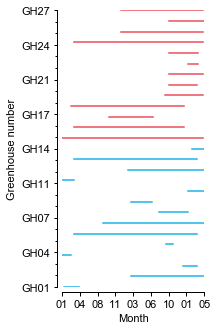

In [15]:
# maximum_x_values = pd.date_range(date_indices.min(), date_indices.max())
fig = plt.figure(figsize=((8/2.54), (6/2.54)*2))
ax0 = plt.subplot()
i = 1
for DATES, ID in zip(pap_indices, papset_list):
    x_values = pd.date_range(DATES[0], DATES[-1])
    ax0.plot(DATES, ['GH' + ('%02d' % i)]*len(DATES), c=raw_cmap[4])
    i += 1

for DATES, ID in zip(tom_indices, tomset_list):
    x_values = pd.date_range(DATES[0], DATES[-1])
    ax0.plot(DATES, ['GH' + ('%02d' % i)]*len(DATES), c=raw_cmap[0])
    i += 1

ax0.spines['right'].set_visible(False)
ax0.spines['left'].set_position(('outward', 5))
ax0.spines['bottom'].set_position(('outward', 5))

ax0.xaxis.set_major_locator(LinearLocator(9))
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%m'))
ax0.set_xbound(pap_indices.min(), pap_indices.max() + pd.Timedelta('1h'))

ax0.yaxis.set_major_locator(LinearLocator(9))
ax0.yaxis.set_minor_locator(LinearLocator(25))
ax0.set_ybound('GH01', 'GH27')

ax0.set_xlabel('Month')
ax0.set_ylabel('Greenhouse number')


fig.tight_layout()
fig.savefig('./figures/Fig1A.svg', transparent=True, format='svg')
plt.show() 

### (B) Sampled data losses

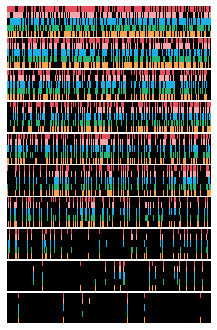

In [16]:
temp_current = []
temp_prev = []
temp_next = []
temp_mask = []
temp_label = []
i = 0

gs = gridspec.GridSpec(10, 1)
fig = plt.figure(figsize=((8/2.54), (6/2.54)*2))
for FILENAME in papset_list[:1]:
    env_df = pd.read_csv(PAP_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate().values
    
    for ___ in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
#         np.random.seed(3101)
        null_prob = 0.3
        mask = np.random.choice(2, env_df.size, p=[null_prob, 1-null_prob]).reshape(env_df.shape)
#         np.random.seed(4564)
        raw_null_prob = ___
        raw_indices = np.random.choice(np.arange(env_df.shape[0]),
                                       replace=False, size=int(env_df.shape[0] * raw_null_prob))

        mask[raw_indices, :] = 0
        missing_df = np.concatenate([[mask.T[0]*.2], [mask.T[1]*.4],
                                     [mask.T[2]*.6], [mask.T[3]*.8], [mask.T[4]]])

        ax0 = fig.add_subplot(gs[i])

        ax0.spines['right'].set_visible(False)
        ax0.spines['left'].set_position(('outward', 5))
        ax0.spines['bottom'].set_visible(False)

        colmap = matplotlib.colors.ListedColormap(['#000000'] + cmap)
# cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
# cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

        plt.setp(ax0.get_xticklabels(), visible=False)
        plt.setp(ax0.get_yticklabels(), visible=False)
        plt.axis('off')
        a = ax0.imshow(missing_df, aspect='auto', cmap=colmap)

        # ax1 = fig.add_subplot(gs[1])
        # ax1.imshow(null_50, aspect='auto', cmap=newcmp)
        # ax1.spines['right'].set_visible(False)
        # ax1.spines['left'].set_position(('outward', 5))
        # ax1.spines['bottom'].set_position(('outward', 5))


        # x_label = ('Oct', 'Feb', 'Jun', 'Oct', 'Feb', 'Jun')
        # x_pos = np.arange(len(x_label))
        # ax1.xaxis.set_major_locator(LinearLocator(len(x_pos)))
        # ax1.set_xticklabels(x_label)


        i += 1

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig("./figures/Fig1B.svg", transparent=True, format="svg")
plt.show()

In [17]:
env_df.shape

(2088, 5)

In [18]:
int(env_df.shape[0]/48 * raw_null_prob)

41

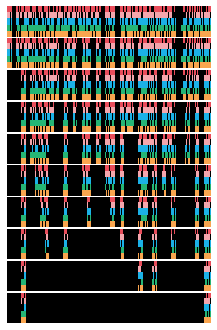

In [19]:
temp_current = []
temp_prev = []
temp_next = []
temp_mask = []
temp_label = []
i = 0

gs = gridspec.GridSpec(10, 1)
fig = plt.figure(figsize=((8/2.54), (6/2.54)*2))
for FILENAME in papset_list[:1]:
    env_df = pd.read_csv(PAP_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate().values
    
    for ___ in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
        np.random.seed(3101)
        null_prob = 0.3
        mask = np.random.choice(2, env_df.size, p=[null_prob, 1-null_prob]).reshape(env_df.shape)
        np.random.seed(4564)
        raw_null_prob = ___
        raw_indices = np.random.choice(np.arange(int(env_df.shape[0]/48)-1),
                                       replace=False, size=int(env_df.shape[0]/48 * raw_null_prob))
        raw_indices = raw_indices*48
        raw_indices_ext = []
        for elem in raw_indices:
            for _ in range(elem, elem+48):
                raw_indices_ext.append(_)
        raw_indices = np.array(raw_indices_ext)
        raw_indices = np.unique(raw_indices[raw_indices < env_df.shape[0]])
        
        mask[raw_indices, :] = 0
        missing_df = np.concatenate([[mask.T[0]*.2], [mask.T[1]*.4],
                                     [mask.T[2]*.6], [mask.T[3]*.8], [mask.T[4]]])

        ax0 = fig.add_subplot(gs[i])

        ax0.spines['right'].set_visible(False)
        ax0.spines['left'].set_position(('outward', 5))
        ax0.spines['bottom'].set_visible(False)

        colmap = matplotlib.colors.ListedColormap(['#000000'] + cmap)
# cmap_m = ["#f4a6ad", "#f6957e", "#fccfa2", "#8de7be", "#86d6f2", "#24a9e4", "#b586e0", "#d7f293"]
# cmap = ["#e94d5b", "#ef4d28", "#f9a54f", "#25b575", "#1bb1e7", "#1477a2", "#a662e5", "#c2f442"]

        plt.setp(ax0.get_xticklabels(), visible=False)
        plt.setp(ax0.get_yticklabels(), visible=False)
        plt.axis('off')
        a = ax0.imshow(missing_df, aspect='auto', cmap=colmap)

        # ax1 = fig.add_subplot(gs[1])
        # ax1.imshow(null_50, aspect='auto', cmap=newcmp)
        # ax1.spines['right'].set_visible(False)
        # ax1.spines['left'].set_position(('outward', 5))
        # ax1.spines['bottom'].set_position(('outward', 5))


        # x_label = ('Oct', 'Feb', 'Jun', 'Oct', 'Feb', 'Jun')
        # x_pos = np.arange(len(x_label))
        # ax1.xaxis.set_major_locator(LinearLocator(len(x_pos)))
        # ax1.set_xticklabels(x_label)


        i += 1

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig("./figures/Fig1B.svg", transparent=True, format="svg")
plt.show()

# Figure 2

### Model structure

# Figure 3

### One-to-one correspondence

In [20]:
fig_size = (8/2.54)*4.5*0.62, (6/2.54)*0.62
bounds = [[-20, 60], [-30, 50], [0, 100], [0, 3000], [-600, 1200]]
M_locators = [3, 3, 3, 3, 3]
m_locators = [7, 7, 7, 7, 7]
gammas = [0.2]*4 + [0.15]

### U-Net

0.43959499394393275
5.061498654474681
[[0.43424496]] [11.79869655]

0.5491866615659351
6.857935243712554
[[0.54356981]] [6.0673917]

0.49094204945775965
9.640872139503479
[[0.5203989]] [43.11465386]

0.429518006909843
121.54068627374235
[[0.4751261]] [239.77099529]

0.36477048993218775
192.69118206759003
[[0.37998724]] [105.00681376]



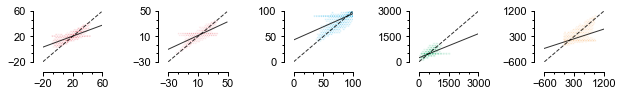

0.4938272761432875
4.811480491353616
[[0.45569689]] [11.43424872]

0.647085857103632
6.069156962994277
[[0.63642215]] [4.15147791]

0.5319637026714921
9.240769310252933
[[0.60274797]] [34.42017469]

0.3266141258407259
132.01046526298668
[[0.45680447]] [220.06294615]

0.5198989653950599
167.353914092229
[[0.49808695]] [62.80767723]



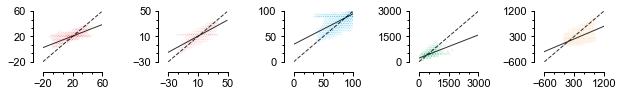

0.6548902685233997
3.9747585320501324
[[0.64829228]] [7.50840395]

0.8454218128188375
4.01836496533001
[[0.84872517]] [2.01510547]

0.7206495389714394
7.136904171518042
[[0.71313663]] [26.36015438]

0.61167132722081
100.26052012176174
[[0.73215901]] [144.95247821]

0.6865095695040553
135.27182026429426
[[0.73532151]] [35.99453512]



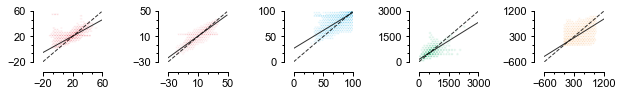

0.7797320767325491
3.179307814917236
[[0.71139667]] [6.13887236]

0.897169944336671
3.2806441243724103
[[0.90867395]] [1.28162023]

0.7604591085692728
6.605328593107926
[[0.8082021]] [16.83364325]

0.5397740817722204
109.06916699325298
[[0.68723082]] [165.0768416]

0.7399298691020838
123.28907709670364
[[0.7442567]] [30.63928411]



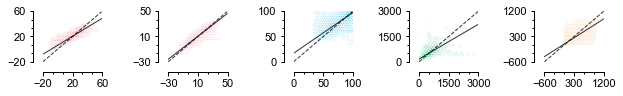

0.7582417034486246
3.3369618885049284
[[0.73114846]] [5.75402951]

0.8805087957992886
3.540594138205783
[[0.91766407]] [1.16329782]

0.6937680545011307
7.464213286515109
[[0.77338683]] [20.02953495]

0.46913029760609815
116.9165016868861
[[0.68419667]] [164.23883889]

0.7291507025134123
125.83559624623416
[[0.8043654]] [33.24751561]



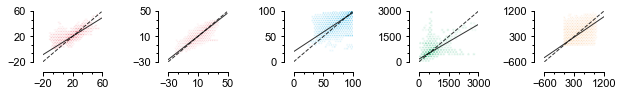

In [21]:
for SIZE in [5, 10, 20, 50, 100]:
    l = np.load('./results/UNet_%dx%d.npz' % (SIZE, SIZE))
    test_label = l['test_label']
    test_pred = l['test_pred']
    
    avg_label = test_label.reshape(-1, 5)
    avg_pred = test_pred.reshape(-1, 5)

    fig = plt.figure(figsize=fig_size)
    grid = plt.GridSpec(1,5)
    for i in range(5):
        ax = plt.subplot(grid[i])
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_position(('outward', 10))
        ax.spines['bottom'].set_position(('outward', 10))
        target_label = avg_label[:, i][~np.isnan(avg_pred[:, i])]
        target_pred = avg_pred[:, i][~np.isnan(avg_pred[:, i])]
        x_linear = np.arange(bounds[i][0], bounds[i][1])
        y_linear = x_linear
        regr = linear_model.LinearRegression()
        regr.fit(target_label.reshape(-1, 1), target_pred.reshape(-1, 1))
        Yp = regr.predict(target_label.reshape(-1, 1))
        reg_x = np.arange(bounds[i][0], bounds[i][1]).reshape(-1, 1)
        reg_y = reg_x*regr.coef_ + regr.intercept_

        reg_line = ax.plot(reg_x, reg_y, 'k-', linewidth=1, alpha=0.8)
        linear = ax.plot(x_linear, y_linear, 'k--', linewidth=1, alpha=0.8)

        ax.hexbin(target_label, target_pred, linewidth=0.5, mincnt=20, edgecolors='w', gridsize=20, norm=mcolors.PowerNorm(gammas[i]), cmap=colmaps[i])
#        ax.scatter(target_label, target_pred, linewidths=0.1, c=cmap[i], s=4, alpha=.1, rasterized=True)        
        ax.set_xbound(bounds[i])
        ax.set_ybound(bounds[i])
        ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
        ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
        ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
        ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
        print(r2_score(target_label, target_pred))
        print(np.sqrt(mean_squared_error(target_label, target_pred)))
        print(regr.coef_, regr.intercept_)
        print()


    fig.tight_layout()
    plt.subplots_adjust(hspace=0.05)
    fig.savefig('./figures/Fig3_UNet_%dx%d.svg' % (SIZE, SIZE), transparent=True, format='svg')
    plt.show()

0.8277227794393013
2.811712277004007
[[0.77265204]] [4.67701167]

0.9013316767440327
3.213571449839948
[[0.91864616]] [0.97740072]

0.7731504004471782
6.427966503561752
[[0.81400675]] [15.62943244]

0.606769469469859
100.81846350811614
[[0.70873977]] [147.70193913]

0.7518395704872469
120.4330345882316
[[0.80734997]] [28.11453985]



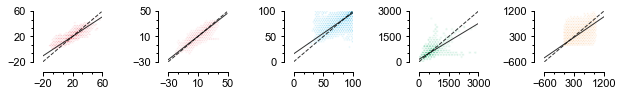

In [22]:
for SIZE in [50]:
    l = np.load('./results/UNet_%dx%d_-1.npz' % (SIZE, SIZE))
    test_label = l['test_label']
    test_pred = l['test_pred']
    
    avg_label = test_label.reshape(-1, 5)
    avg_pred = test_pred.reshape(-1, 5)

    fig = plt.figure(figsize=fig_size)
    grid = plt.GridSpec(1,5)
    for i in range(5):
        ax = plt.subplot(grid[i])
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_position(('outward', 10))
        ax.spines['bottom'].set_position(('outward', 10))
        target_label = avg_label[:, i][~np.isnan(avg_pred[:, i])]
        target_pred = avg_pred[:, i][~np.isnan(avg_pred[:, i])]
        x_linear = np.arange(bounds[i][0], bounds[i][1])
        y_linear = x_linear
        regr = linear_model.LinearRegression()
        regr.fit(target_label.reshape(-1, 1), target_pred.reshape(-1, 1))
        Yp = regr.predict(target_label.reshape(-1, 1))
        reg_x = np.arange(bounds[i][0], bounds[i][1]).reshape(-1, 1)
        reg_y = reg_x*regr.coef_ + regr.intercept_

        reg_line = ax.plot(reg_x, reg_y, 'k-', linewidth=1, alpha=0.8)
        linear = ax.plot(x_linear, y_linear, 'k--', linewidth=1, alpha=0.8)

        ax.hexbin(target_label, target_pred, linewidth=0.5, mincnt=20, edgecolors='w', gridsize=20, norm=mcolors.PowerNorm(gammas[i]), cmap=colmaps[i])
#        ax.scatter(target_label, target_pred, linewidths=0.1, c=cmap[i], s=4, alpha=.1, rasterized=True)        
        ax.set_xbound(bounds[i])
        ax.set_ybound(bounds[i])
        ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
        ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
        ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
        ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
        print(r2_score(target_label, target_pred))
        print(np.sqrt(mean_squared_error(target_label, target_pred)))
        print(regr.coef_, regr.intercept_)
        print()


    fig.tight_layout()
    plt.subplots_adjust(hspace=0.05)
    fig.savefig('./figures/Fig3_UNet_%dx%d.svg' % (SIZE, SIZE), transparent=True, format='svg')
    plt.show()

### FFNN & RNN & Linear interpolation

In [23]:
l = np.load('./results/FFNN.npz')
test_label = l['test_label']
test_pred = l['test_pred']

0.18533008259160133
6.102039178520812
[[0.18911641]] [16.7046906]

0.16599496960932536
9.328808181219223
[[0.23287098]] [8.85838238]

0.019802957423525225
13.382108004767954
[[0.06618108]] [83.6957223]

0.09594029683293392
153.05304928060002
[[0.20331132]] [368.76325031]

0.3461625522373808
195.45240257602376
[[0.34976441]] [103.80811246]



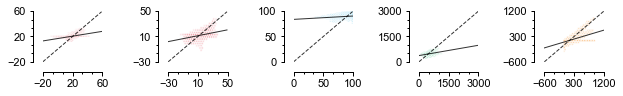

In [24]:
fig = plt.figure(figsize=fig_size)
grid = plt.GridSpec(1,5)
for i in range(5):
    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    target_label = test_label[:, i][~np.isnan(test_pred[:, i])]
    target_pred = test_pred[:, i][~np.isnan(test_pred[:, i])]
    x_linear = np.arange(bounds[i][0], bounds[i][1])
    y_linear = x_linear
    regr = linear_model.LinearRegression()
    regr.fit(target_label.reshape(-1, 1), target_pred.reshape(-1, 1))
    Yp = regr.predict(target_label.reshape(-1, 1))
    reg_x = np.arange(bounds[i][0], bounds[i][1]).reshape(-1, 1)
    reg_y = reg_x*regr.coef_ + regr.intercept_

    reg_line = ax.plot(reg_x, reg_y, 'k-', linewidth=1, alpha=0.8)
    linear = ax.plot(x_linear, y_linear, 'k--', linewidth=1, alpha=0.8)

    ax.hexbin(target_label, target_pred, linewidth=0.5, mincnt=20, edgecolors='w', gridsize=20, norm=mcolors.PowerNorm(gammas[i]), cmap=colmaps[i])
#        ax.scatter(target_label, target_pred, linewidths=0.1, c=cmap[i], s=4, alpha=.1, rasterized=True)        
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
    print(r2_score(target_label, target_pred))
    print(np.sqrt(mean_squared_error(target_label, target_pred)))
    print(regr.coef_, regr.intercept_)
    print()


fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig('./figures/Fig3_FFNN.svg', transparent=True, format='svg')
plt.show()

In [25]:
l = np.load('./results/RNN_100x100.npz')
test_label = l['test_label']
test_pred = l['test_pred']

In [26]:
avg_label = test_label.reshape(-1, 5)
avg_pred = test_pred.reshape(-1, 5)

0.2667745386722824
5.770984173514941
[[0.25665726]] [15.08905843]

0.2820332167273457
8.547853751221366
[[0.37270545]] [7.59844169]

0.027646868447684603
13.059904802116161
[[0.06681883]] [83.57674862]

0.1588387728033368
146.460752745829
[[0.2052332]] [376.96381628]

0.16632017191876158
221.35184050368485
[[0.23130675]] [133.08142138]



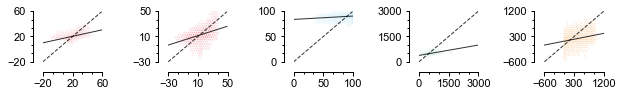

In [27]:
fig = plt.figure(figsize=fig_size)
grid = plt.GridSpec(1,5)
for i in range(5):
    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    target_label = avg_label[:, i][~np.isnan(avg_pred[:, i])]
    target_pred = avg_pred[:, i][~np.isnan(avg_pred[:, i])]
    x_linear = np.arange(bounds[i][0], bounds[i][1])
    y_linear = x_linear
    regr = linear_model.LinearRegression()
    regr.fit(target_label.reshape(-1, 1), target_pred.reshape(-1, 1))
    Yp = regr.predict(target_label.reshape(-1, 1))
    reg_x = np.arange(bounds[i][0], bounds[i][1]).reshape(-1, 1)
    reg_y = reg_x*regr.coef_ + regr.intercept_

    reg_line = ax.plot(reg_x, reg_y, 'k-', linewidth=1, alpha=0.8)
    linear = ax.plot(x_linear, y_linear, 'k--', linewidth=1, alpha=0.8)

    ax.hexbin(target_label, target_pred, linewidth=0.5, mincnt=20, edgecolors='w', gridsize=20, norm=mcolors.PowerNorm(gammas[i]), cmap=colmaps[i])
#        ax.scatter(target_label, target_pred, linewidths=0.1, c=cmap[i], s=4, alpha=.1, rasterized=True)        
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
    print(r2_score(target_label, target_pred))
    print(np.sqrt(mean_squared_error(target_label, target_pred)))
    print(regr.coef_, regr.intercept_)
    print()


fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig('./figures/Fig3_RNN.svg', transparent=True, format='svg')
plt.show()

In [28]:
l = np.load('./results/Linear_interpol.npz')
test_label = l['test_label']
test_pred = l['test_pred']

0.7063445344191956
3.573156424284714
[[0.79405903]] [2.60445714]

0.8785138827381623
3.5044560106511518
[[0.91328974]] [-0.09238882]

0.7582635205363375
6.624256835494465
[[0.85110048]] [13.60084372]

0.6168403525066147
99.72679317852156
[[0.70237463]] [168.98836915]

0.16598203666445843
216.71555041964817
[[0.38908503]] [7.68476053]



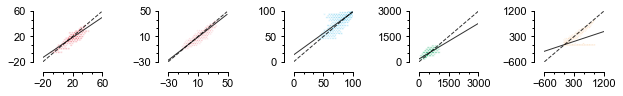

In [29]:
fig = plt.figure(figsize=fig_size)
grid = plt.GridSpec(1,5)
for i in range(5):
    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    target_label = test_label[:, i][~np.isnan(test_pred[:, i])]
    target_pred = test_pred[:, i][~np.isnan(test_pred[:, i])]
    x_linear = np.arange(bounds[i][0], bounds[i][1])
    y_linear = x_linear
    regr = linear_model.LinearRegression()
    regr.fit(target_label.reshape(-1, 1), target_pred.reshape(-1, 1))
    Yp = regr.predict(target_label.reshape(-1, 1))
    reg_x = np.arange(bounds[i][0], bounds[i][1]).reshape(-1, 1)
    reg_y = reg_x*regr.coef_ + regr.intercept_

    reg_line = ax.plot(reg_x, reg_y, 'k-', linewidth=1, alpha=0.8)
    linear = ax.plot(x_linear, y_linear, 'k--', linewidth=1, alpha=0.8)

    ax.hexbin(target_label, target_pred, linewidth=0.5, mincnt=20, edgecolors='w', gridsize=20, norm=mcolors.PowerNorm(gammas[i]), cmap=colmaps[i])
#    ax.scatter(target_label, target_pred, linewidths=0.1, c=cmap[i], s=4, alpha=.1, rasterized=True)        
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
    print(r2_score(target_label, target_pred))
    print(np.sqrt(mean_squared_error(target_label, target_pred)))
    print(regr.coef_, regr.intercept_)
    print()


fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig('./figures/Fig3_LinInt.svg', transparent=True, format='svg')
plt.show()

# Figure 4

### Accruacy for various losses

In [47]:
fig_size = (8/2.54)*4.5*0.62, (6/2.54)*2*0.62
y_bounds = [[0, 8], [0, 12], [0, 30], [0, 500], [0, 400]]
LOSS_RATES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

### U-Net

In [31]:
R2_table = {}
RMSE_table = {}
for LOSS_RATE in LOSS_RATES:
    l = np.load('./results/UNet_best_loss_%.2fp.npz' % LOSS_RATE)
    test_label = l['test_label']
    test_pred = l['test_pred']
    
    avg_label = test_label.reshape(-1, 5)
    avg_pred = test_pred.reshape(-1, 5)

    R2_table['loss_%.2fp' % LOSS_RATE] = []
    RMSE_table['loss_%.2fp' % LOSS_RATE] = []
    for i in range(5):
        target_label = avg_label[:, i][~np.isnan(avg_pred[:, i])]
        target_pred = avg_pred[:, i][~np.isnan(avg_pred[:, i])]

        R2_table['loss_%.2fp' % LOSS_RATE].append(r2_score(target_label.reshape(-1, 1), target_pred.reshape(-1, 1)))
        RMSE_table['loss_%.2fp' % LOSS_RATE].append(np.sqrt(mean_squared_error(target_label.reshape(-1, 1), target_pred.reshape(-1, 1))))

In [32]:
UNet_R2_df = pd.DataFrame(R2_table)
UNet_R2_df[UNet_R2_df < 0] = 0
UNet_RMSE_df = pd.DataFrame(RMSE_table)

### LSTM

In [33]:
R2_table = {}
RMSE_table = {}
for LOSS_RATE in LOSS_RATES:
    l = np.load('./results/RNN_%.2fp.npz' % LOSS_RATE)
    test_label = l['test_label']
    test_pred = l['test_pred']

    avg_label = test_label.reshape(-1, 5)
    avg_pred = test_pred.reshape(-1, 5)

    R2_table['loss_%.2fp' % LOSS_RATE] = []
    RMSE_table['loss_%.2fp' % LOSS_RATE] = []
    
    for i in range(5):
        target_label = avg_label[:, i][~np.isnan(avg_pred[:, i])]
        target_pred = avg_pred[:, i][~np.isnan(avg_pred[:, i])]

        R2_table['loss_%.2fp' % LOSS_RATE].append(r2_score(target_label.reshape(-1, 1), target_pred.reshape(-1, 1)))
        RMSE_table['loss_%.2fp' % LOSS_RATE].append(np.sqrt(mean_squared_error(target_label.reshape(-1, 1), target_pred.reshape(-1, 1))))

In [34]:
LSTM_R2_df = pd.DataFrame(R2_table)
LSTM_R2_df[LSTM_R2_df < 0] = 0
LSTM_RMSE_df = pd.DataFrame(RMSE_table)

### FFNN & Linear interpolation

In [35]:
R2_table = {}
RMSE_table = {}
for LOSS_RATE in LOSS_RATES:
    l = np.load('./results/FFNN_%.2fp.npz' % LOSS_RATE)
    test_label = l['test_label']
    test_pred = l['test_pred']

    R2_table['loss_%.2fp' % LOSS_RATE] = []
    RMSE_table['loss_%.2fp' % LOSS_RATE] = []
    for i in range(5):
        target_label = test_label[:, i][~np.isnan(test_pred[:, i])]
        target_pred = test_pred[:, i][~np.isnan(test_pred[:, i])]

        R2_table['loss_%.2fp' % LOSS_RATE].append(r2_score(target_label.reshape(-1, 1), target_pred.reshape(-1, 1)))
        RMSE_table['loss_%.2fp' % LOSS_RATE].append(np.sqrt(mean_squared_error(target_label.reshape(-1, 1), target_pred.reshape(-1, 1))))

In [36]:
FFNN_R2_df = pd.DataFrame(R2_table)
FFNN_R2_df[FFNN_R2_df < 0] = 0
FFNN_RMSE_df = pd.DataFrame(RMSE_table)

In [37]:
R2_table = {}
RMSE_table = {}
for LOSS_RATE in LOSS_RATES:
    l = np.load('./results/Linear_interpol_loss_%.2fp.npz' % LOSS_RATE)
    test_label = l['test_label']
    test_pred = l['test_pred']

    R2_table['loss_%.2fp' % LOSS_RATE] = []
    RMSE_table['loss_%.2fp' % LOSS_RATE] = []
    for i in range(5):
        target_label = test_label[:, i][~np.isnan(test_pred[:, i])]
        target_pred = test_pred[:, i][~np.isnan(test_pred[:, i])]

        R2_table['loss_%.2fp' % LOSS_RATE].append(r2_score(target_label.reshape(-1, 1), target_pred.reshape(-1, 1)))
        RMSE_table['loss_%.2fp' % LOSS_RATE].append(np.sqrt(mean_squared_error(target_label.reshape(-1, 1), target_pred.reshape(-1, 1))))

In [38]:
LI_R2_df = pd.DataFrame(R2_table)
LI_R2_df[LI_R2_df < 0] = 0
LI_RMSE_df = pd.DataFrame(RMSE_table)

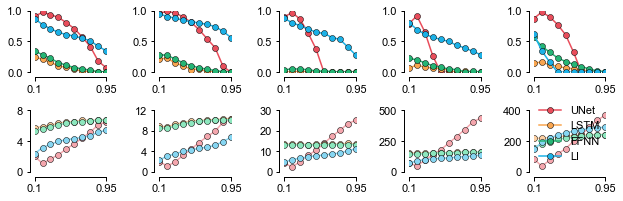

In [49]:
x_t = [str(_) for _ in LOSS_RATES]
fig = plt.figure(figsize=fig_size)
grid = plt.GridSpec(2,5)
for _ in range(5):
    ax = plt.subplot(grid[_])
    R2_1, = ax.plot(x_t, UNet_R2_df.values[_, :], 'o-', mew=0.5, mec='k', c=raw_cmap[0])
    R2_2, = ax.plot(x_t, LSTM_R2_df.values[_, :], 'o-', mew=0.5, mec='k', c=raw_cmap[2])
    R2_3, = ax.plot(x_t, FFNN_R2_df.values[_, :], 'o-', mew=0.5, mec='k', c=raw_cmap[3])
    R2_4, = ax.plot(x_t, LI_R2_df.values[_, :], 'o-', mew=0.5, mec='k', c=raw_cmap[4])
    
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    
    ax.set_xbound([x_t[0], x_t[-1]])
    ax.set_ybound([0, 1])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))

locates = [3, 4, 4, 3, 3]
x_t = [str(_) for _ in LOSS_RATES]
for _ in range(5):
    ax = plt.subplot(grid[_+5])
    RMSE2_1, = ax.plot(x_t, UNet_RMSE_df.values[_, :], 'o-', mew=0.5, mec='k', c=raw_cmap_m[0])
    RMSE2_2, = ax.plot(x_t, LSTM_RMSE_df.values[_, :], 'o-', mew=0.5, mec='k', c=raw_cmap_m[2])
    RMSE2_3, = ax.plot(x_t, FFNN_RMSE_df.values[_, :], 'o-', mew=0.5, mec='k', c=raw_cmap_m[3])
    RMSE2_4, = ax.plot(x_t, LI_RMSE_df.values[_, :], 'o-', mew=0.5, mec='k', c=raw_cmap_m[4])
    
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    
    ax.set_xbound([x_t[0], x_t[-1]])
    ax.set_ybound(y_bounds[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(locates[_]))


plt.legend([R2_1, R2_2, R2_3, R2_4], ['UNet', 'LSTM', 'FFNN', 'LI'], frameon=False)
fig.tight_layout()
fig.savefig('./figures/Fig4.svg', transparent=True, format='svg')
plt.show()

# Table 1

### Ranges of data

In [41]:
MAXS = [-500]*5
MINS = [500]*5
for FILENAME in papset_list:
    env_df = pd.read_csv(PAP_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate().values
    for i in range(5):
#         if i == 3:
#             if env_df[:, i][env_df[:, i] >10].max(axis=0) > MAXS[i]:
#                 MAXS[i] = env_df[:, i][env_df[:, i] >0].max(axis=0)
#             if env_df[:, i][env_df[:, i] >10].min(axis=0) < MINS[i]:
#                 MINS[i] = env_df[:, i][env_df[:, i] >0].min(axis=0)
#                 if MINS[i] == 1.67:
#                     print(FILENAME)
#             continue
        if env_df.max(axis=0)[i] > MAXS[i]:
            MAXS[i] = env_df.max(axis=0)[i]
        if env_df.min(axis=0)[i] < MINS[i]:
            MINS[i] = env_df.min(axis=0)[i]
            
print(MAXS)
print(MINS)

[54.88, 37.35, 101.27, 2999.0, 1027.7]
[5.32, -21.18, 19.38, 1.67, 0.0]


In [42]:
MAXS = [-500]*5
MINS = [500]*5
for FILENAME in tomset_list:
    env_df = pd.read_csv(TOM_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate().values
    for i in range(5):
        if i == 3:
            if env_df[:, i][env_df[:, i] >10].max(axis=0) > MAXS[i]:
                MAXS[i] = env_df[:, i][env_df[:, i] >0].max(axis=0)
            if env_df[:, i][env_df[:, i] >10].min(axis=0) < MINS[i]:
                MINS[i] = env_df[:, i][env_df[:, i] >0].min(axis=0)
                if MINS[i] == 1.67:
                    print(FILENAME)
            continue
        if env_df.max(axis=0)[i] > MAXS[i]:
            MAXS[i] = env_df.max(axis=0)[i]
        if env_df.min(axis=0)[i] < MINS[i]:
            MINS[i] = env_df.min(axis=0)[i]

print(MAXS)
print(MINS)

[60.25, 37.95, 100.0, 2382.08, 1669.92]
[-10.14, -14.72, 5.86, 36.64, 0.0]


# Figure XX

### DISUSE

fig = plt.figure(figsize=((8/2.54)*1.7, (6/2.54)*2))
grid = plt.GridSpec(5,1)
x_t = np.arange(env_df.shape[0])
Y_BOUNDS = [[10, 40], [-25, 35], [85, 100], [100, 1000], [0, 1100]]
COLOR_CODE = [0, 1, 4, 3, 2]
i=10
for _ in range(5):
    ax = plt.subplot(grid[_])
    measured1 = ax.plot(x_t, env_df.values[:, _], c=cmap[COLOR_CODE[_]])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    ax.set_xbound([24*i, 24*(i+10)])
    ax.set_ybound(Y_BOUNDS[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))
    ax.axes.xaxis.set_ticklabels([])

fig.tight_layout()
# fig.savefig('./figures/Fig1A.svg', transparent=True, format='svg')
# # fig.savefig('./figures/Fig6A.png', transparent=True, dpi=600, format='png')
plt.show()

fig = plt.figure(figsize=((8/2.54)*1.7, (6/2.54)*2))
grid = plt.GridSpec(5,1)
x_t = np.arange(env_df.shape[0])
Y_BOUNDS = [[10, 40], [-25, 35], [85, 100], [100, 1000], [0, 1100]]
COLOR_CODE = [0, 1, 4, 3, 2]
i=20
for _ in range(5):
    ax = plt.subplot(grid[_])
    measured1 = ax.plot(x_t, env_df.values[:, _], c=cmap[COLOR_CODE[_]])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    ax.set_xbound([24*i, 24*(i+10)])
    ax.set_ybound(Y_BOUNDS[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))
    ax.axes.xaxis.set_ticklabels([])

fig.tight_layout()
# fig.savefig('./figures/Fig1B.svg', transparent=True, format='svg')
# # fig.savefig('./figures/Fig6A.png', transparent=True, dpi=600, format='png')
plt.show()

fig = plt.figure(figsize=((8/2.54)*1.7, (6/2.54)*2))
grid = plt.GridSpec(5,1)
x_t = np.arange(env_df.shape[0])
Y_BOUNDS = [[10, 40], [-25, 35], [85, 100], [100, 1200], [0, 1100]]
COLOR_CODE = [0, 1, 4, 3, 2]
i=0
for _ in range(5):
    ax = plt.subplot(grid[_])
    measured1 = ax.plot(x_t, env_df.values[:, _], c=cmap[COLOR_CODE[_]])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    ax.set_xbound([24*i, 24*(i+10)])
    ax.set_ybound(Y_BOUNDS[_])
    ax.xaxis.set_major_locator(LinearLocator(2))
    ax.yaxis.set_major_locator(LinearLocator(3))
    ax.axes.xaxis.set_ticklabels([])

fig.tight_layout()
# fig.savefig('./figures/Fig1C.svg', transparent=True, format='svg')
# # fig.savefig('./figures/Fig6A.png', transparent=True, dpi=600, format='png')
plt.show()

### DISUSE

temp_current = []
temp_prev = []
temp_next = []
temp_mask = []
temp_label = []
i = 0

gs = gridspec.GridSpec(27, 1)
fig = plt.figure(figsize=((8/2.54), (6/2.54)*2))
for FILENAME in papset_list:
    env_df = pd.read_csv(PAP_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate().values
    
    np.random.seed(3101)
    null_prob = 0.3
    mask = np.random.choice(2, env_df.size, p=[null_prob, 1-null_prob]).reshape(env_df.shape)
    np.random.seed(4564)
    raw_null_prob = 0.5
    raw_indices = np.random.choice(np.arange(env_df.shape[0]),
                                   replace=False, size=int(env_df.shape[0] * raw_null_prob))
    
    mask[raw_indices, :] = 0
    missing_df = np.concatenate([[mask.T[0]*.2], [mask.T[1]*.4],
                                 [mask.T[2]*.6], [mask.T[3]*.8], [mask.T[4]]])

    ax0 = fig.add_subplot(gs[i])

    ax0.spines['right'].set_visible(False)
    ax0.spines['left'].set_position(('outward', 5))
    ax0.spines['bottom'].set_visible(False)

    colmap = matplotlib.colors.ListedColormap(['#000000'] + cmap[:-1])

    plt.setp(ax.get_xticklabels(), visible=False)
    plt.setp(ax.get_yticklabels(), visible=False)
    plt.axis('off')
    a = ax0.imshow(missing_df, aspect='auto', cmap=colmap)

    # ax1 = fig.add_subplot(gs[1])
    # ax1.imshow(null_50, aspect='auto', cmap=newcmp)
    # ax1.spines['right'].set_visible(False)
    # ax1.spines['left'].set_position(('outward', 5))
    # ax1.spines['bottom'].set_position(('outward', 5))


    # x_label = ('Oct', 'Feb', 'Jun', 'Oct', 'Feb', 'Jun')
    # x_pos = np.arange(len(x_label))
    # ax1.xaxis.set_major_locator(LinearLocator(len(x_pos)))
    # ax1.set_xticklabels(x_label)

    
    i += 1

for FILENAME in tomset_list:
    env_df = pd.read_csv(TOM_DIRECTORY + FILENAME, index_col=['MEAS_DATE']).dropna(how='all')
    env_df = env_df[~(env_df == 0).all(axis=1)].interpolate().values
    
    np.random.seed(3101)
    null_prob = 0.3
    mask = np.random.choice(2, env_df.size, p=[null_prob, 1-null_prob]).reshape(env_df.shape)
    np.random.seed(4564)
    raw_null_prob = 0.2
    raw_indices = np.random.choice(np.arange(env_df.shape[0]),
                                   replace=False, size=int(env_df.shape[0] * raw_null_prob))
    
    mask[raw_indices, :] = 0
    missing_df = np.concatenate([[mask.T[0]*.2], [mask.T[1]*.4],
                                 [mask.T[2]*.6], [mask.T[3]*.8], [mask.T[4]]])

    ax0 = fig.add_subplot(gs[i])

    ax0.spines['right'].set_visible(False)
    ax0.spines['left'].set_position(('outward', 5))
    ax0.spines['bottom'].set_visible(False)

    colmap = matplotlib.colors.ListedColormap(['#000000'] + cmap[:-1])

    plt.setp(ax.get_xticklabels(), visible=False)
    plt.setp(ax.get_yticklabels(), visible=False)
    plt.axis('off')
    a = ax0.imshow(missing_df, aspect='auto', cmap=colmap)

    # ax1 = fig.add_subplot(gs[1])
    # ax1.imshow(null_50, aspect='auto', cmap=newcmp)
    # ax1.spines['right'].set_visible(False)
    # ax1.spines['left'].set_position(('outward', 5))
    # ax1.spines['bottom'].set_position(('outward', 5))


    # x_label = ('Oct', 'Feb', 'Jun', 'Oct', 'Feb', 'Jun')
    # x_pos = np.arange(len(x_label))
    # ax1.xaxis.set_major_locator(LinearLocator(len(x_pos)))
    # ax1.set_xticklabels(x_label)

    
    i += 1

fig.tight_layout()
# plt.subplots_adjust(hspace=0.1)
# fig.savefig("./figures/Fig3.svg", transparent=True, format="svg")
plt.show()

### DISUSE

fig = plt.figure(figsize=((8/2.54)*4.5, (6/2.54)))
grid = plt.GridSpec(1,5)
bounds = [[-15, 60], [-25, 45], [30, 110], [0, 2500], [0, 1200]]
M_locators = [6, 8, 5, 6, 5]
m_locators = [16, 15, 9, 11, 9]
gammas = [0.05, 0.1, 0.06, 0.1, 0.05]
for i in range(5):
    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    target_label = avg_label[:, i][~np.isnan(avg_pred[:, i])]
    target_pred = avg_pred[:, i][~np.isnan(avg_pred[:, i])]

    ax.hist2d(target_label, target_pred, bins=100, norm=mcolors.PowerNorm(gammas[i]), cmap=colmaps[i], rasterized=True)
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
#     print(r2_score(target_label, target_pred))
#     print(np.sqrt(mean_squared_error(target_label, target_pred)))
c#     print()

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig("./figures/Fig3.svg", transparent=True, format="svg")
plt.show()

fig = plt.figure(figsize=((8/2.54)*4.5, (6/2.54)))
grid = plt.GridSpec(1,5)
bounds = [[-15, 60], [-25, 45], [30, 110], [0, 2500], [0, 1200]]
M_locators = [6, 8, 5, 6, 5]
m_locators = [16, 15, 9, 11, 9]
gammas = [0.05, 0.1, 0.06, 0.1, 0.05]
for i in range(5):
    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    target_label = avg_label[:, i][~np.isnan(avg_pred[:, i])]
    target_pred = avg_pred[:, i][~np.isnan(avg_pred[:, i])]

    heatmap, xedges, yedges = np.histogram2d(target_label, target_pred, bins=10)
#     heatmap = gaussian_filter(heatmap, sigma=32)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    
    ax.imshow(heatmap, extent=extent, origin='lower', cmap=colmaps[i])
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
#     print(r2_score(target_label, target_pred))
#     print(np.sqrt(mean_squared_error(target_label, target_pred)))
#     print()

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig("./figures/Fig3.svg", transparent=True, format="svg")
plt.show()

fig = plt.figure(figsize=((8/2.54)*4.5, (6/2.54)))
grid = plt.GridSpec(1,5)
bounds = [[-15, 60], [-25, 45], [30, 110], [0, 2500], [0, 1200]]
M_locators = [6, 8, 5, 6, 5]
m_locators = [16, 15, 9, 11, 9]
gammas = [0.05, 0.1, 0.06, 0.1, 0.05]
for i in range(5):
    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    target_label = avg_label[:, i][~np.isnan(avg_pred[:, i])]
    target_pred = avg_pred[:, i][~np.isnan(avg_pred[:, i])]

   
    ax.hist2d(target_label, target_pred, bins=30, norm=mcolors.PowerNorm(gammas[i]), cmap=colmaps[i], rasterized=True)
    
#     np.random.seed(7755)
#     target_label = np.random.choice(target_label, size=1000)
#     np.random.seed(7755)
#     target_pred = np.random.choice(target_pred, size=1000)
    ax.scatter(target_label, target_pred, linewidths=.1, edgecolors='k', c=cmap[i], s=4, alpha=0.5, rasterized=True)
    
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
#     print(r2_score(target_label, target_pred))
#     print(np.sqrt(mean_squared_error(target_label, target_pred)))
#     print()

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
fig.savefig("./figures/Fig3.svg", transparent=True, format="svg")
plt.show()

fig = plt.figure(figsize=((8/2.54)*4.5, (6/2.54)))
grid = plt.GridSpec(1,5)
bounds = [[-15, 60], [-25, 45], [30, 110], [0, 2500], [0, 1200]]
M_locators = [6, 8, 5, 6, 5]
m_locators = [16, 15, 9, 11, 9]
for i in range(5):
    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    target_label = avg_label[:, i][~np.isnan(avg_pred[:, i])]
    target_pred = avg_pred[:, i][~np.isnan(avg_pred[:, i])]

    np.random.seed(7755)
    np.random.choice(target_label, size=1000)
    np.random.seed(7755)
    np.random.choice(target_pred, size=1000)
    # Calculate the point density
    xy = np.vstack([target_label,target_pred])
    z = gaussian_kde(xy)(xy)

    # Sort the points by density, so that the densest points are plotted last
    idx = z.argsort()
    target_label, target_pred, z = target_label[idx], target_pred[idx], z[idx]
    
    ax.scatter(target_label, target_pred, c=z, s=4, alpha=.1)
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
#     print(r2_score(target_label, target_pred))
#     print(np.sqrt(mean_squared_error(target_label, target_pred)))
#     print()

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
#fig.savefig("./figures/Fig3.svg", transparent=True, format="svg")
plt.show()

fig = plt.figure(figsize=((8/2.54)*4.5, (6/2.54)))
grid = plt.GridSpec(1,5)
bounds = [[-15, 60], [-25, 45], [30, 110], [0, 2500], [0, 1200]]
M_locators = [6, 8, 5, 6, 5]
m_locators = [16, 15, 9, 11, 9]
for i in range(5):
    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    target_label = avg_label[:, i][~np.isnan(avg_pred[:, i])]
    target_pred = avg_pred[:, i][~np.isnan(avg_pred[:, i])]

    ax.scatter(target_label, target_pred, linewidths=0.1, c=cmap[i], s=4, alpha=.1)
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
#     print(r2_score(target_label, target_pred))
#     print(np.sqrt(mean_squared_error(target_label, target_pred)))
#     print()

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
#fig.savefig("./figures/Fig3.svg", transparent=True, format="svg")
plt.show()

def bin_by(x, y, nbins=30, bins = None):
    """
    Divide the x axis into sections and return groups of y based on its x value
    """
    if bins is None:
        bins = np.linspace(x.min(), x.max(), nbins)

    bin_space = (bins[-1] - bins[0])/(len(bins)-1)/2

    indicies = np.digitize(x, bins + bin_space)

    output = []
    for i in range(0, len(bins)):
        output.append(y[indicies==i])
    #
    # prepare a dataframe with cols: median; mean; 1up, 1dn, 2up, 2dn, 3up, 3dn
    df_names = ['mean'] + ['%sth' % int(num) for num in range(5, 100, 5)]
    df = pd.DataFrame(columns = df_names)
    to_delete = []
    # for each bin, determine the std ranges
    for y_set in output:
        if y_set.size > 0:
            av = y_set.mean()
            intervals = np.percentile(y_set, q = [num for num in range(5, 100, 5)])
            res = [av] + list(intervals)
            df = df.append(pd.DataFrame([res], columns = df_names))
        else:
            # just in case there are no elements in the bin
            to_delete.append(len(df) + 1 + len(to_delete))
            

    # add x values
    bins = np.delete(bins, to_delete)
    df['x'] = bins

    return df

fig = plt.figure(figsize=((8/2.54)*4.5, (6/2.54)))
grid = plt.GridSpec(1,5)
bounds = [[-15, 60], [-25, 45], [30, 110], [0, 2500], [0, 1200]]
M_locators = [6, 8, 5, 6, 5]
m_locators = [16, 15, 9, 11, 9]
for i in range(5):
    ax = plt.subplot(grid[i])
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_position(('outward', 5))
    ax.spines['bottom'].set_position(('outward', 5))
    target_label = avg_label[:, i][~np.isnan(avg_pred[:, i])]
    target_pred = avg_pred[:, i][~np.isnan(avg_pred[:, i])]
    
    df = bin_by(target_label, target_pred, nbins=100, bins = None)
    for _ in range(5, 50, 5):
        plt.fill_between(df.x, df['%sth' % _], df['%sth' % (100-_)], alpha=0.5, color = cmap[i])
    # plt the line
    plt.plot(df.x, df['50th'], color =cmap[i], alpha = 1, linewidth = 1)
    # plot the points
    
    ax.set_xbound(bounds[i])
    ax.set_ybound(bounds[i])
    ax.xaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.xaxis.set_minor_locator(LinearLocator(m_locators[i]))
    ax.yaxis.set_major_locator(LinearLocator(M_locators[i]))
    ax.yaxis.set_minor_locator(LinearLocator(m_locators[i]))
#     print(r2_score(target_label, target_pred))
#     print(np.sqrt(mean_squared_error(target_label, target_pred)))
#     print()

fig.tight_layout()
plt.subplots_adjust(hspace=0.05)
#fig.savefig("./figures/Fig3.svg", transparent=True, format="svg")
plt.show()